In [22]:
import pandas as pd
import numpy as np


red = pd.read_csv(
    "winequality-red.csv",
    sep=";"
)

white = pd.read_csv(
    "winequality-white.csv",
    sep=";"
)

red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

red["type"] = "red"
white["type"] = "white"

wine = pd.concat([red, white], ignore_index=True)

chem_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

print('Красное вино:', red.shape)
print('Белое вино:', white.shape)
print('Объединенный датасет:', wine.shape)

wine.head()

Красное вино: (1599, 13)
Белое вино: (4898, 13)
Объединенный датасет: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [23]:
wine_dedup = (
    wine
    .drop_duplicates()
    .reset_index(drop=True)
)


wine_work = wine_dedup.copy()

print("\nИтоговый размер датасета:")
print(wine_work.shape)


Итоговый размер датасета:
(5320, 13)


In [24]:
wine_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5320 entries, 0 to 5319
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5320 non-null   float64
 1   volatile acidity      5320 non-null   float64
 2   citric acid           5320 non-null   float64
 3   residual sugar        5320 non-null   float64
 4   chlorides             5320 non-null   float64
 5   free sulfur dioxide   5320 non-null   float64
 6   total sulfur dioxide  5320 non-null   float64
 7   density               5320 non-null   float64
 8   pH                    5320 non-null   float64
 9   sulphates             5320 non-null   float64
 10  alcohol               5320 non-null   float64
 11  quality               5320 non-null   int64  
 12  type                  5320 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 540.4+ KB


## 1. Описательные статистики

In [25]:
wine_work.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


## 2. Распределение признаков

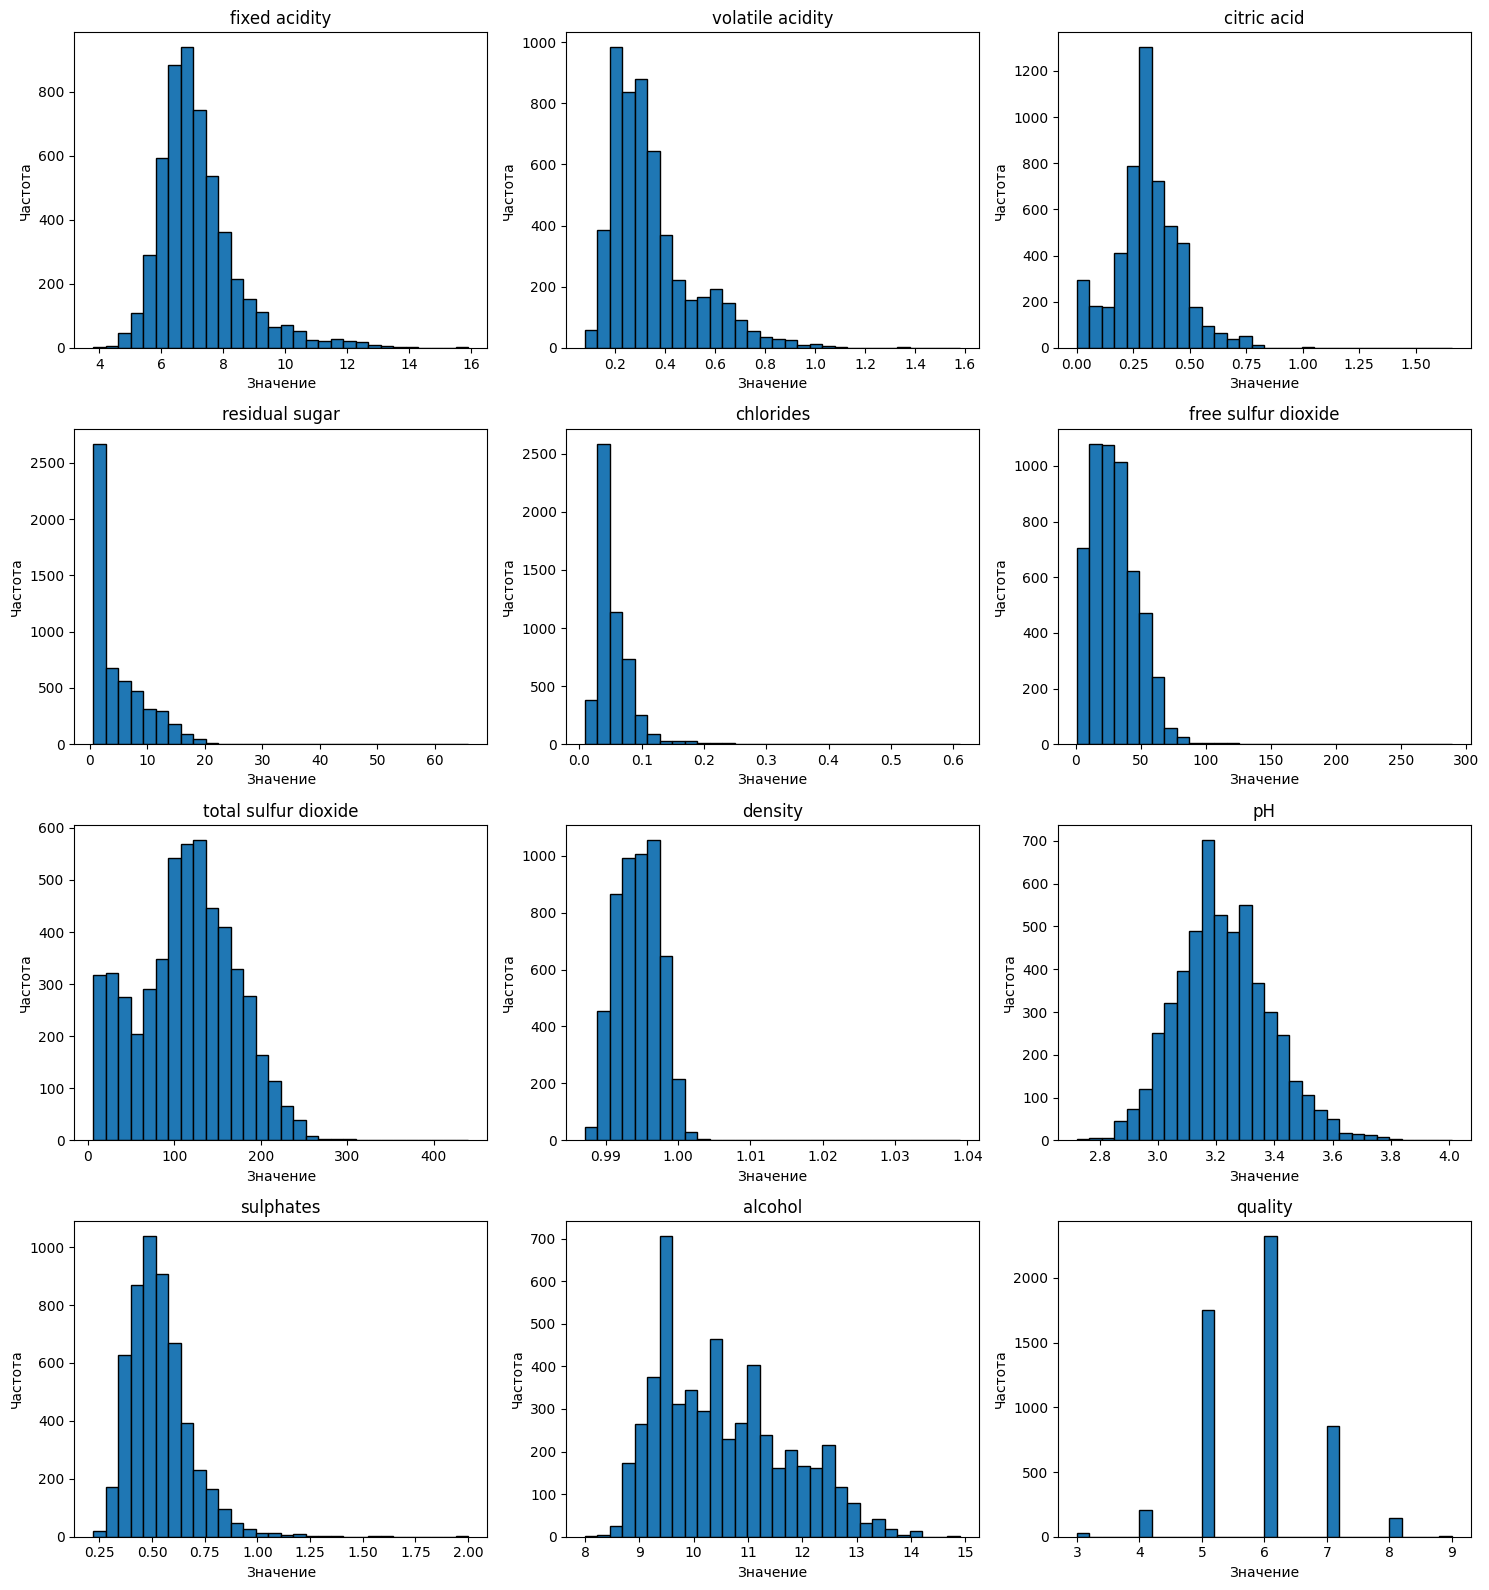

In [26]:
import matplotlib.pyplot as plt
import numpy as np

n_cols = len(wine_work.columns) - 1

nrows = int(np.ceil(n_cols / 3))
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(wine_work.columns):
    if col == 'type':
        continue
    axes[i].hist(wine_work[col], bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Видно, что распределения некоторых признаков скошено влево. Проверим количество уникальных значений и логарифмируем

In [27]:
wine_work[[
    'fixed acidity',
    'volatile acidity',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'sulphates'
]].nunique()

,0
fixed acidity,106
volatile acidity,187
residual sugar,316
chlorides,214
free sulfur dioxide,135
sulphates,111


In [28]:
wine_log = wine_work.copy()

cols_to_log = [
    'fixed acidity',
    'volatile acidity',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'sulphates'
]

for col in cols_to_log:
    wine_log[col] = np.log1p(wine_log[col])

Посмотрим, как выглядят распределения

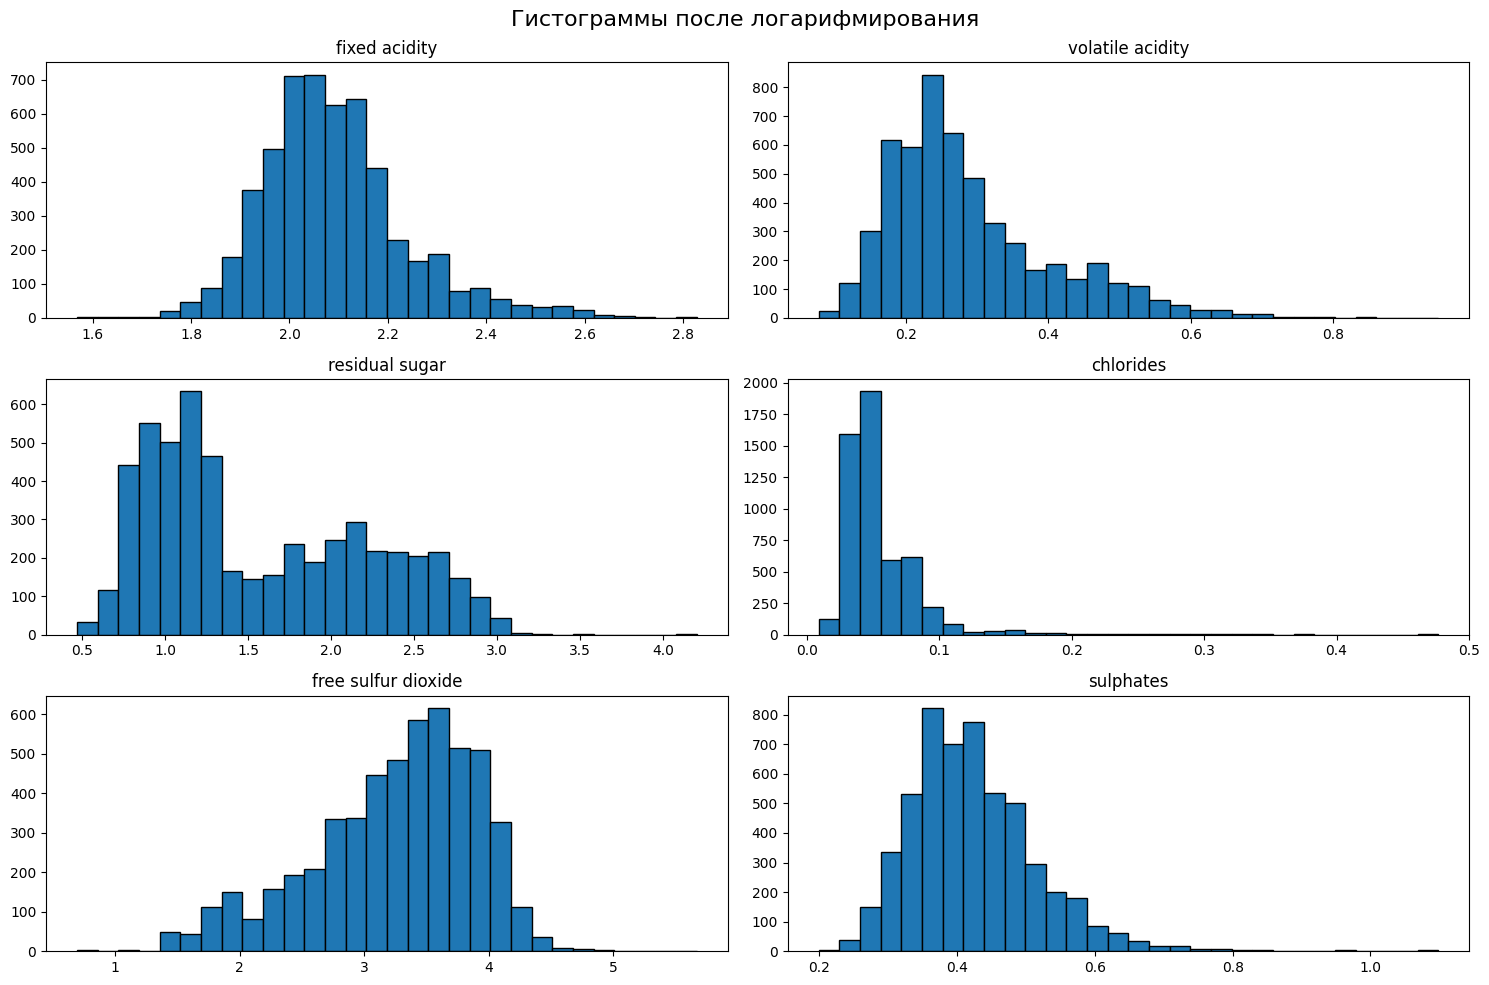

In [29]:
wine_log[cols_to_log].hist(
    figsize=(15, 10),
    bins=30,
    edgecolor='black'
)

for ax in plt.gcf().axes:
    ax.grid(False)

plt.suptitle('Гистограммы после логарифмирования', fontsize=16)
plt.tight_layout()
plt.show()

Распределения residual sugar и volatile acidity имеют два максимума, визуализируем зависимость с целевой переменной

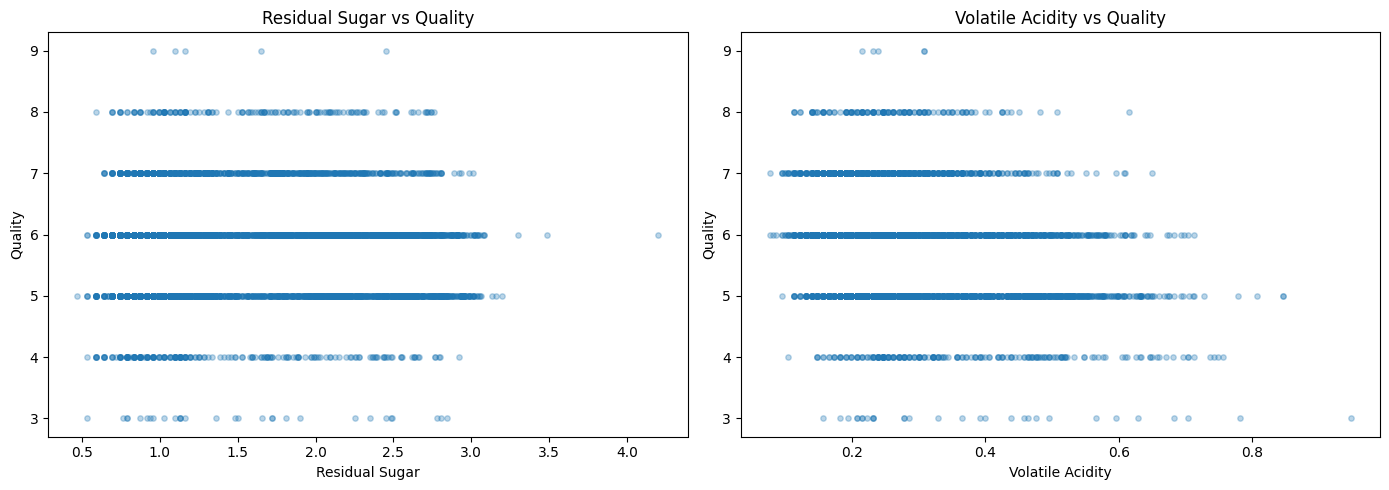

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    wine_log['residual sugar'],
    wine_log['quality'],
    s=15,
    alpha=0.3
)

axes[1].scatter(
    wine_log['volatile acidity'],
    wine_log['quality'],
    s=15,
    alpha=0.3
)

axes[0].set_title('Residual Sugar vs Quality')
axes[0].set_xlabel('Residual Sugar')
axes[0].set_ylabel('Quality')

axes[1].set_title('Volatile Acidity vs Quality')
axes[1].set_xlabel('Volatile Acidity')
axes[1].set_ylabel('Quality')

for ax in axes:
    ax.grid(False)

plt.tight_layout()
plt.show()

В разделении мультимодальных признаков нет смысла. Остальные распределения близки к нормальным

Построим боксплоты признаков в разьивке по quality для оценки зависимости целевой переменной от признаков

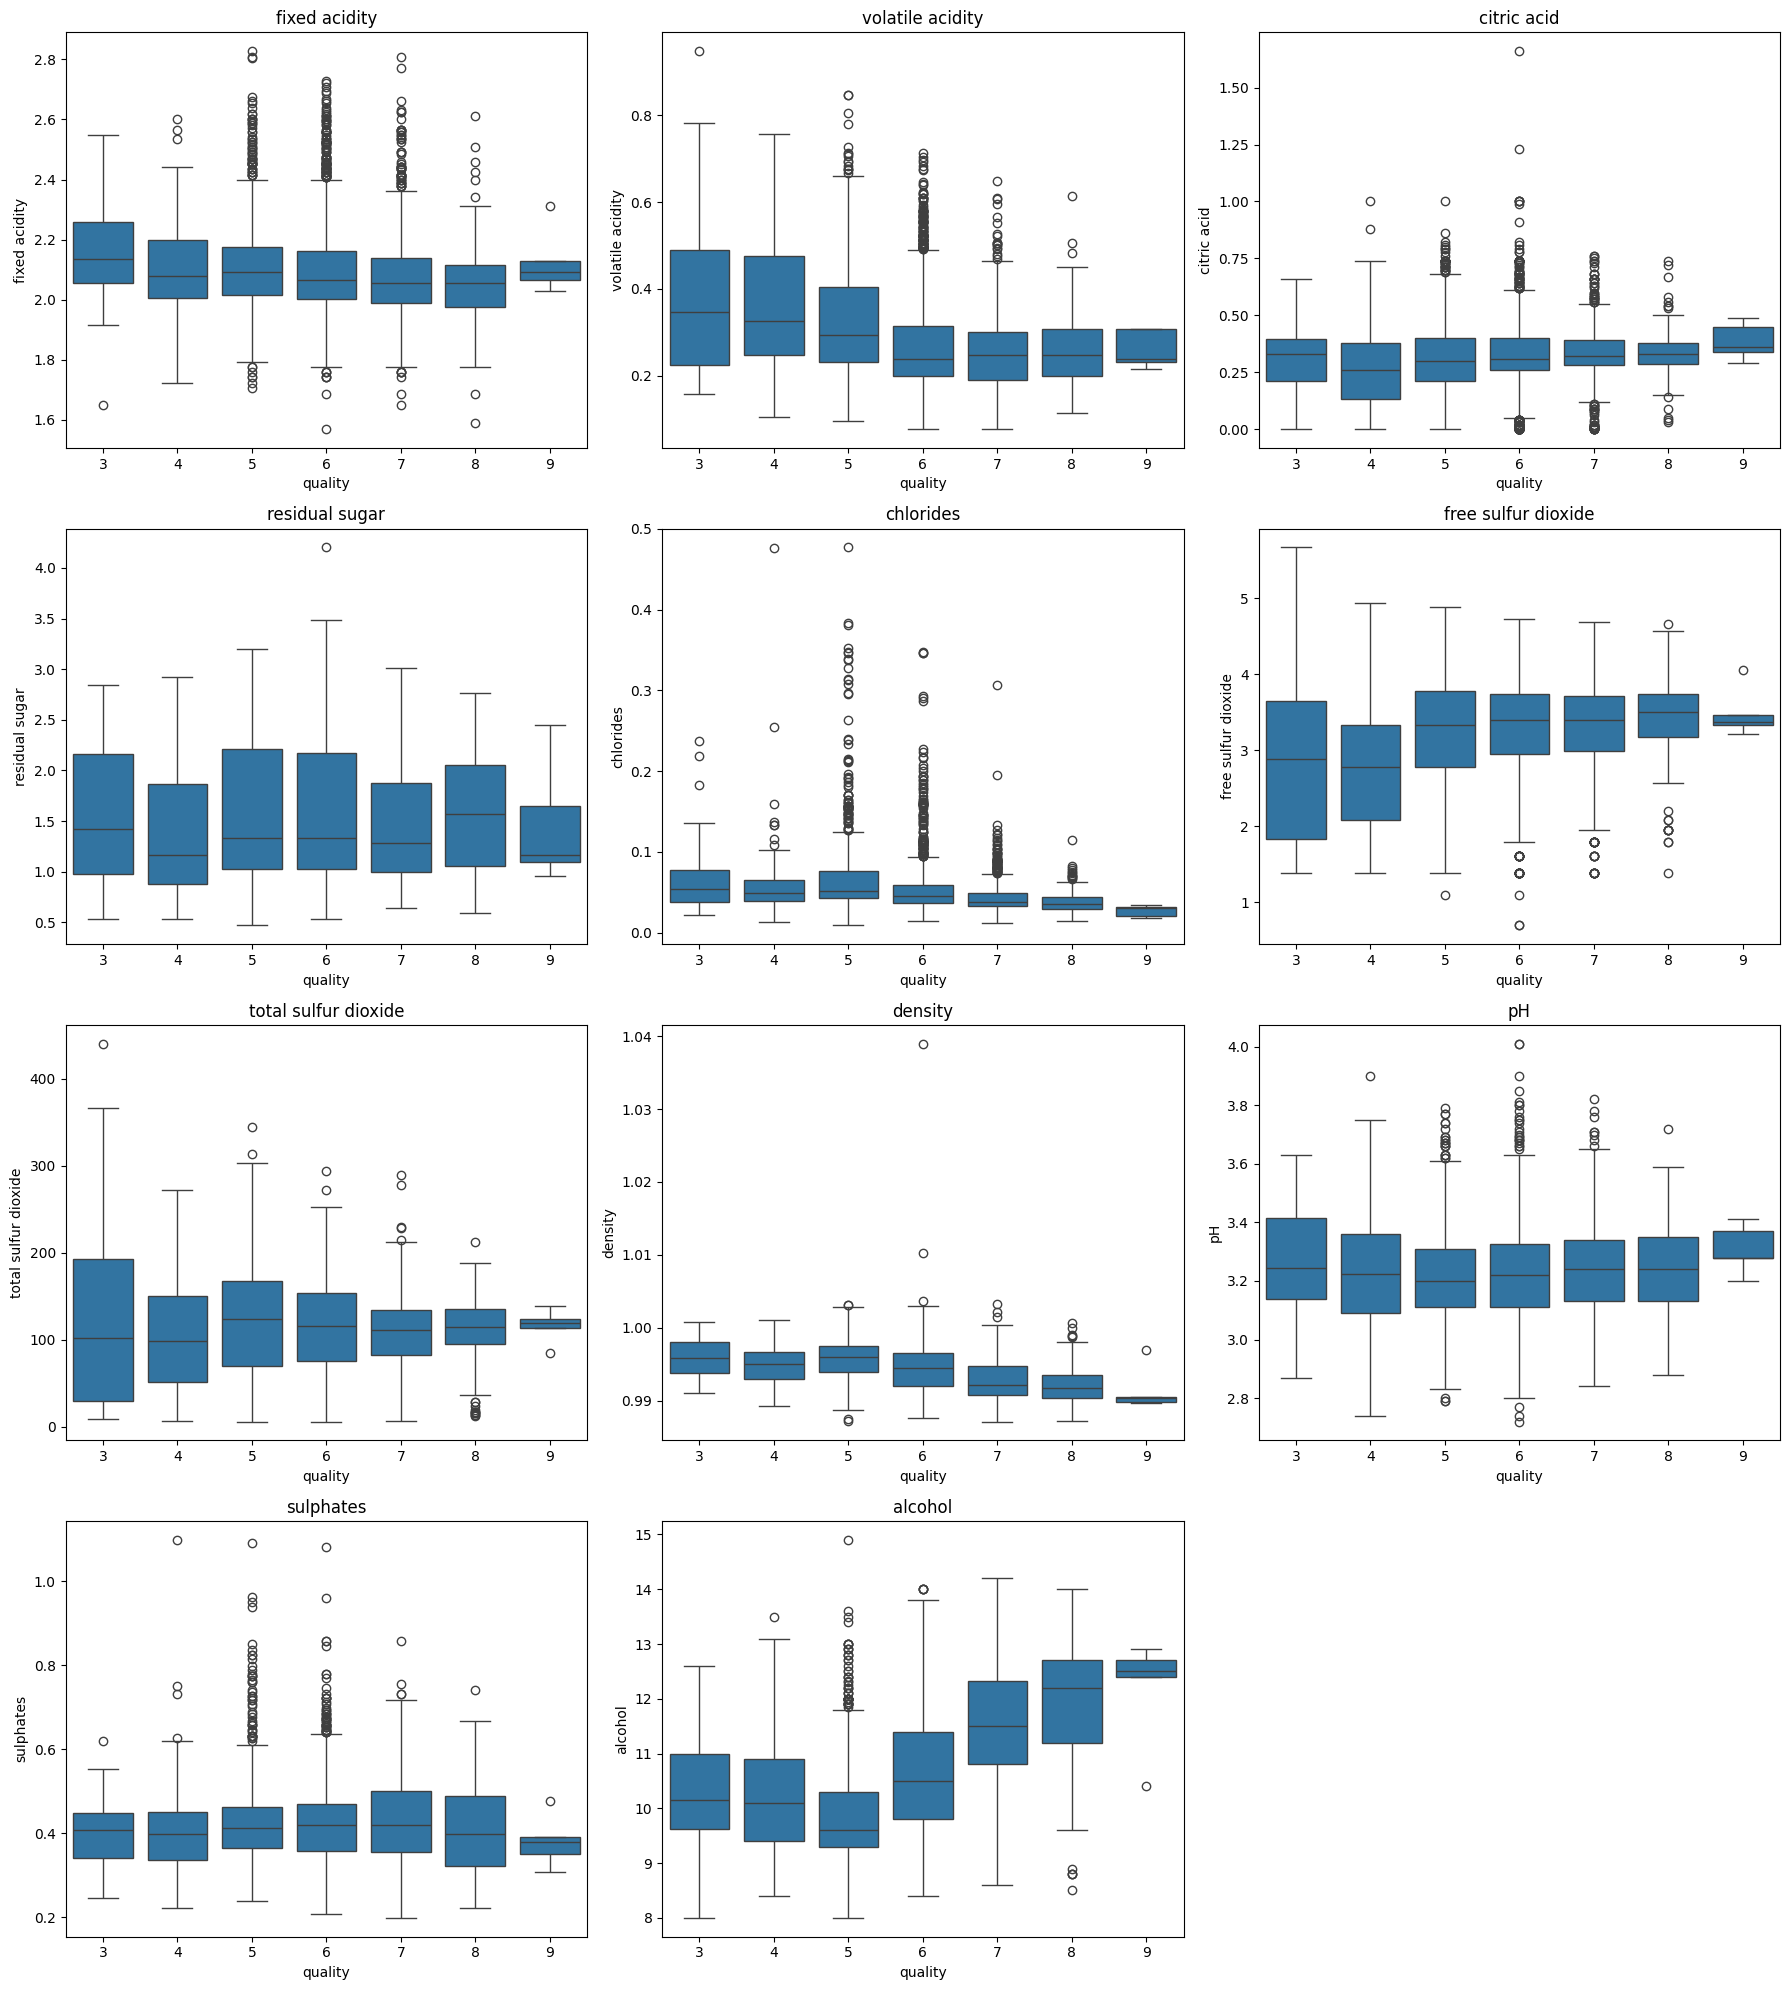

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

features = [col for col in wine_log.columns if col not in ['quality', 'type']]

ncols = 3
nrows = int(np.ceil(len(features) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=wine_log,
        x='quality',
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].grid(False)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Будем использовать это при выборе исключаемых признаков после корреляций

##3. Выбросы

По гистограммам были видны тяжелые хвосты, поэтому требуется обработка выбросов. Ранее на этапе предобработки мы отмечали большое количествог выбросов по IQR, попробуем посмотреть по Z-статистике

In [ ]:
def three_sigma_outliers(series):
    mean = series.mean()
    std = series.std()

    lower = mean - 3 * std
    upper = mean + 3 * std

    anomaly_mask = (series < lower) | (series > upper)
    anomaly_percent = anomaly_mask.mean() * 100

    return anomaly_mask, anomaly_percent

In [33]:
features = [col for col in wine_work.columns if col not in ['quality', 'type']]

outlier_stats = {}

for col in features:
    mask, percent = three_sigma_outliers(wine_log[col])
    outlier_stats[col] = percent

pd.DataFrame.from_dict(
    outlier_stats,
    orient='index',
    columns=['outlier_percent']
).sort_values('outlier_percent', ascending=False)

,outlier_percent
chlorides,1.879699
fixed acidity,1.447368
sulphates,1.033835
volatile acidity,0.996241
pH,0.601504
citric acid,0.488722
total sulfur dioxide,0.150376
free sulfur dioxide,0.093985
density,0.056391
alcohol,0.037594


Так размечается меньший процент выбросов, так что выкинем их

In [35]:
total_anomaly_mask = np.zeros(len(wine_log), dtype=bool)

for col in features:
    mask, _ = three_sigma_outliers(wine_log[col])
    total_anomaly_mask |= mask

wine_no_outliers = wine_log.loc[~total_anomaly_mask].copy()

print(f'Исходный размер: {wine_work.shape}')
print(f'После удаления аномалий: {wine_no_outliers.shape}')
print(f'Удаленное в разбивке по типам: {wine_log[total_anomaly_mask]['type'].value_counts()}')

Исходный размер: (5320, 13)
После удаления аномалий: (5000, 13)
Удаленное в разбивке по типам: type
red      219
white    101
Name: count, dtype: int64


Построим боксплоты без аномалий

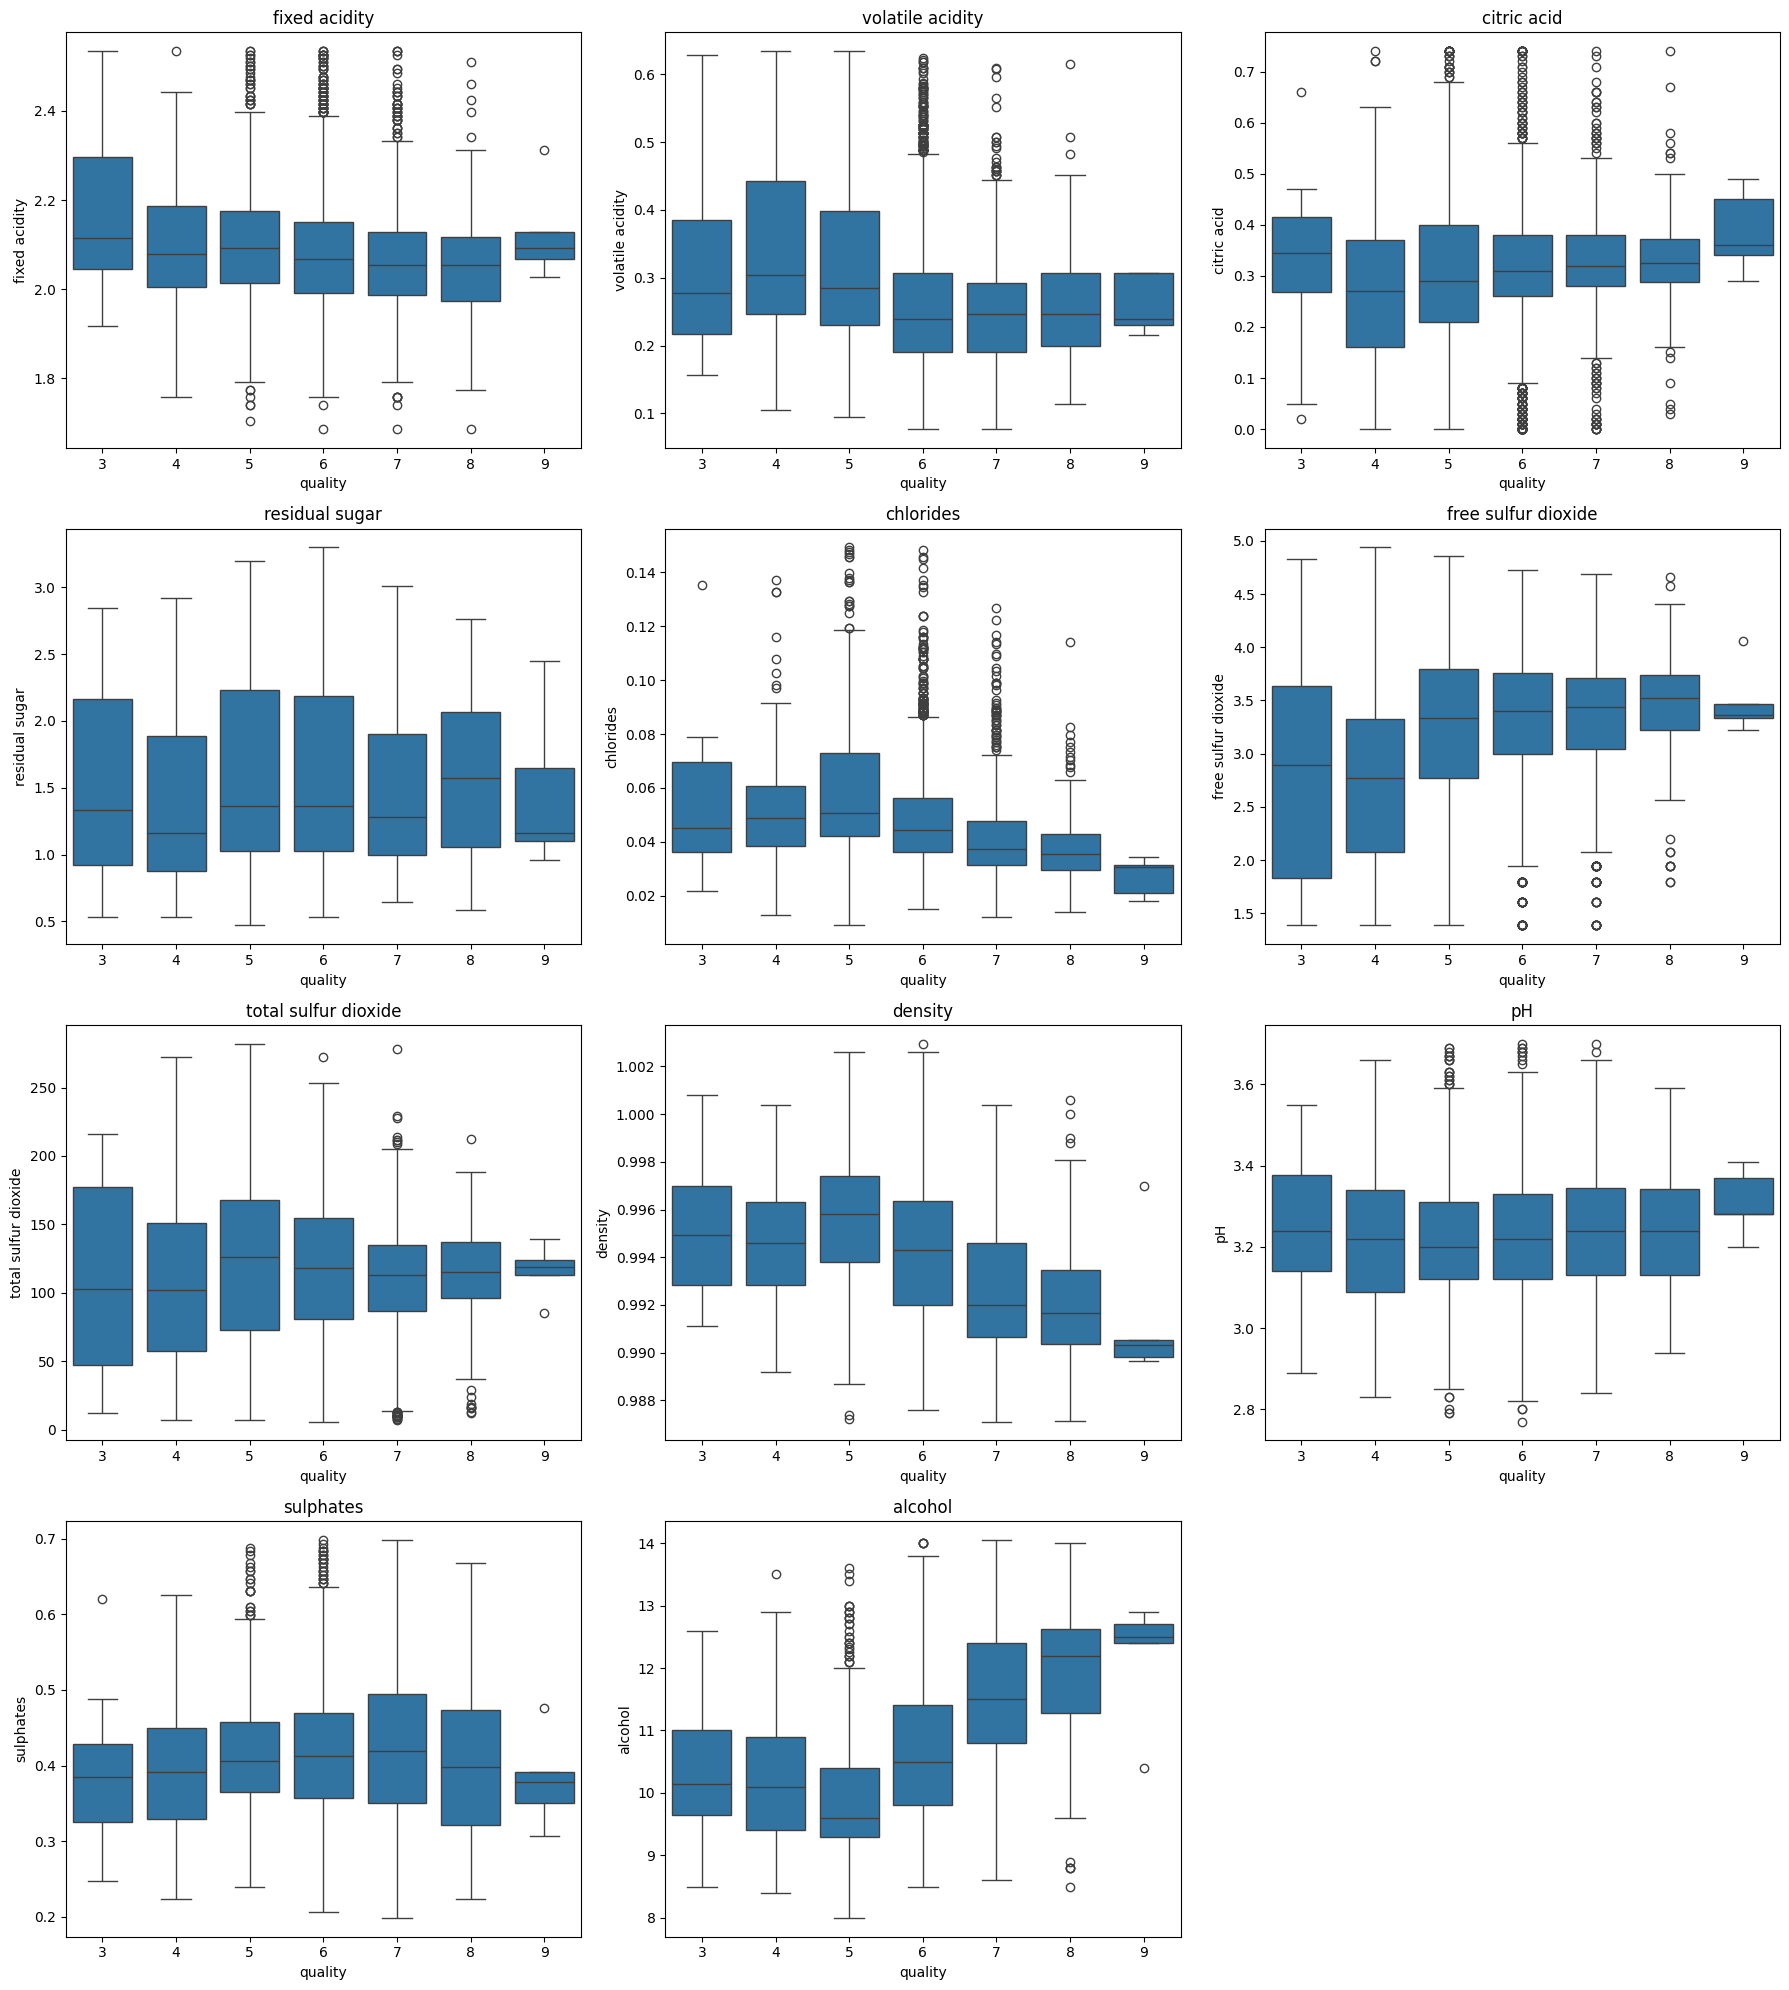

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

features = [col for col in wine_log.columns if col not in ['quality', 'type']]

ncols = 3
nrows = int(np.ceil(len(features) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=wine_no_outliers,
        x='quality',
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].grid(False)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4.Корреляционный анализ

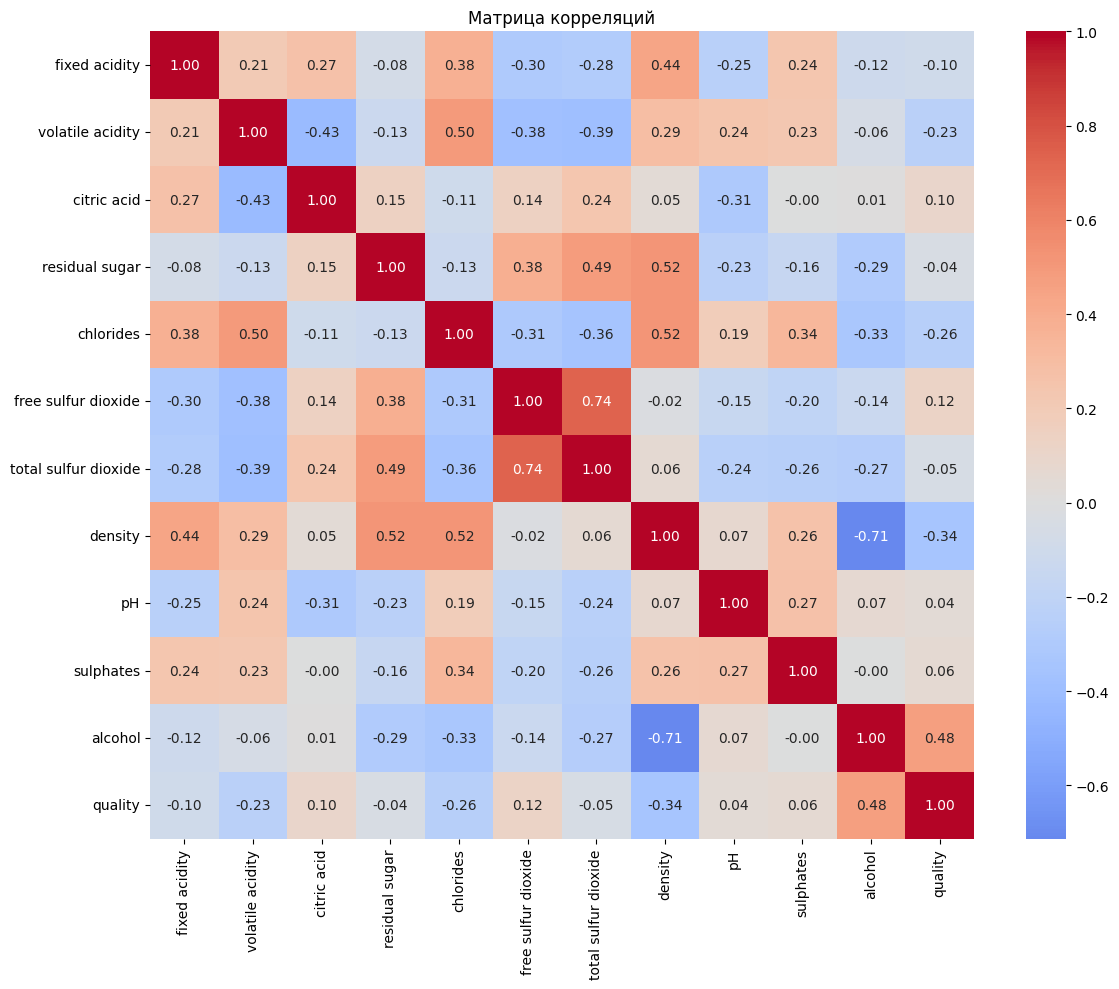

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = wine_no_outliers.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

In [40]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = wine_no_outliers.drop(columns=['quality', 'type'])

X_scaled = StandardScaler().fit_transform(X)

vif = pd.DataFrame({
    'feature': X.columns,
    'VIF': [
        variance_inflation_factor(X_scaled, i)
        for i in range(X_scaled.shape[1])
    ]
})

vif = vif.sort_values('VIF', ascending=False)

vif

,feature,VIF
7,density,14.558585
3,residual sugar,5.597716
10,alcohol,5.184761
0,fixed acidity,3.555439
6,total sulfur dioxide,3.088719
5,free sulfur dioxide,2.305455
4,chlorides,2.221029
8,pH,2.200793
1,volatile acidity,1.930593
2,citric acid,1.582871


Однозначно стоит убрать density, сильно коррелирует сразу с тремя нецелевыми признаками, высокий VIF. Так же свободный и общий диоксид серы сильно коррелируют, один из них лучше убрать. Корреляции с целевой переменной одинаковые, но по боксплотам видно, что свободный диоксид распределен по quality разнообразнее, чем общий, поэтому остаим его

In [37]:
wine_new = wine_no_outliers.drop(
    columns=['total sulfur dioxide', 'density']
)

Посмотрим на новую корреляционную матрицу

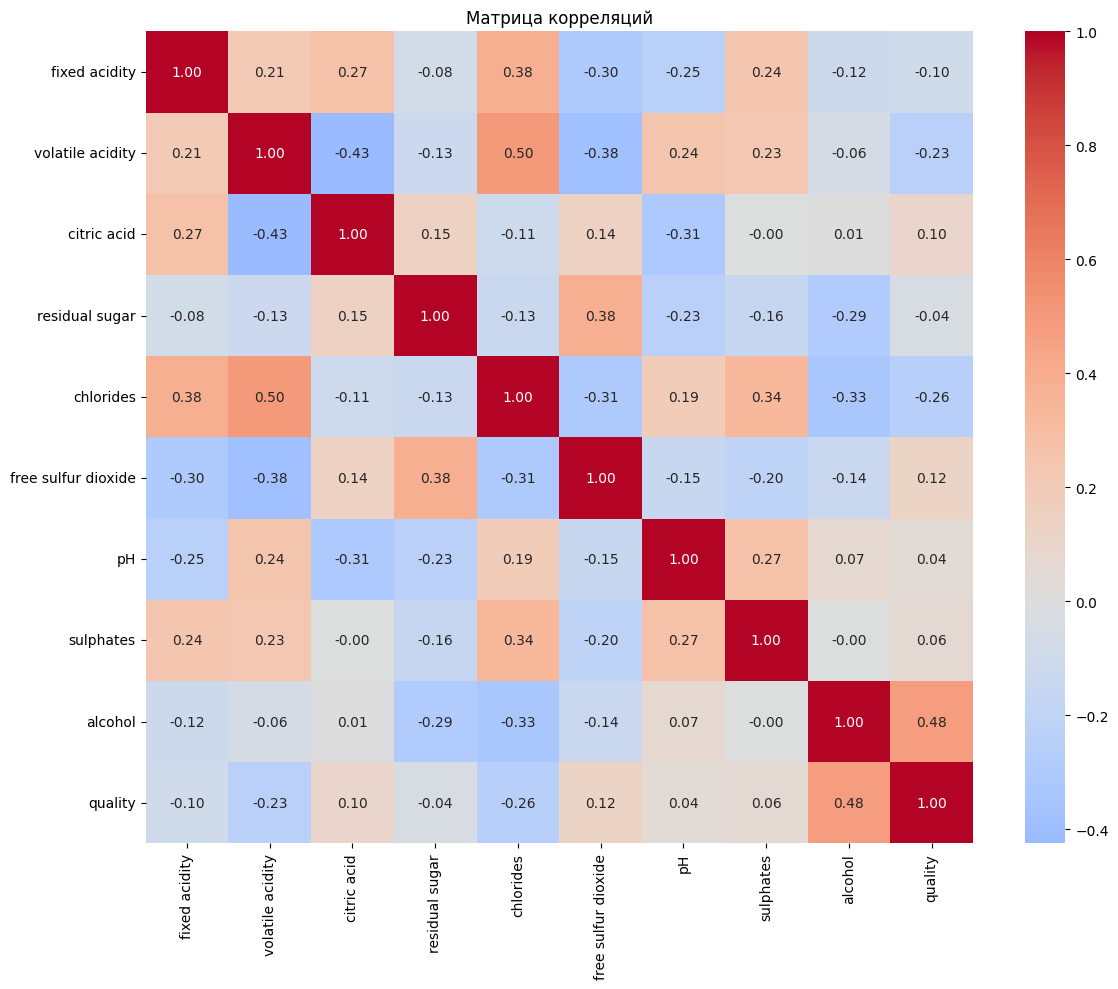

In [38]:
corr_matrix = wine_new.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

## 5. Выводы

1. По гистограммам были выбраны признаки, которыен необходимо логарифмировать для уменьшения асимметрии и снижения влияния экстремальных значений
2. Гистограммы показали наличие тяжелых хвостов в распределениях, что говорит о необходимости в обработке выбросов. В исследовании, проведенном ранее, говорилось о большом в процентном соотношении количестве выбросов по IQR - этой проблемы удалось избежать, изменив метод и заменив признаки со скошенным распрелением на логарифмированные. Количество удаленных аномалий в разбивке по типу вина получилось пропорционально общему количеству белого и красного вин в датасете
3. Матрица корреляций показала необходимость в удалении признака denisty, как коррелирующего с большинством из оставшихся нецелевых признаком, а также имеющего большой коэффициент инфляции дисперсии. Так же нашлась пара признаков по содержанию диоксида серы, сильно коррелирующих попарно, в связи с чем один из них был удален. Выбор осуществлялся с использованием боксплотов признаков с разбивкой по качеству.
4. Итоговый датасет требует масштабирования, после чего готов к обучению и подходит в том числе для линейных моделей.